# Library dan Konfigurasi

## Import Library

In [42]:
import ast
import io
import json
import os
import re
import shutil
import subprocess
import sys
import stat
import time
import tokenize
from collections import defaultdict
from datetime import datetime
import pickle
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score


# Formatter untuk standarisasi kode Python
import autopep8
import black

# Engine export Excel untuk pandas
import openpyxl

# Progress bar & notebook display
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# Waktu
run_time = datetime.now()

# Konfigurasi visualisasi default
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 65)
print(f"{'LIBRARY INITIALIZATION':^65}")
print("-" * 65)
print(f"Python     : {sys.version.split()[0]}")
print(f"✅ {run_time.strftime('%Y-%m-%d %H:%M:%S')} - Libraries loaded successfully.")
print("-" * 65)

                     LIBRARY INITIALIZATION                      
-----------------------------------------------------------------
Python     : 3.10.6
✅ 2026-06-03 08:20:07 - Libraries loaded successfully.
-----------------------------------------------------------------


## Konfigurasi

In [43]:
# ==============================================================================
# DIRECTORY CONFIGURATION & INITIALIZATION
# Menentukan path utama, struktur folder dataset, dan file output
# ==============================================================================

# Root directory dan file input
BASE_DIR = r"D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code"
DATASET_FOLDER = "dataset(2)"
OUTPUT_FOLDER = "output(2)"

INPUT_GITHUB = os.path.join(BASE_DIR, "asli", "nim_github.txt")

# Struktur folder pipeline
DIRS = {
    "DATASET"      : os.path.join(BASE_DIR, DATASET_FOLDER),

    # Preprocessing
    "RAW"          : os.path.join(BASE_DIR, DATASET_FOLDER, "01_Raw"),
    "NORM"         : os.path.join(BASE_DIR, DATASET_FOLDER, "02_Normalized"),
    "CONV"         : os.path.join(BASE_DIR, DATASET_FOLDER, "03_Converted"),
    "CLEAN"        : os.path.join(BASE_DIR, DATASET_FOLDER, "04_Cleaned"),

    # Formatter experiment
    "AUTOPEP8"     : os.path.join(BASE_DIR, DATASET_FOLDER, "05a_Autopep8"),
    "BLACK"        : os.path.join(BASE_DIR, DATASET_FOLDER, "05b_Black"),
    
    "FILTERED"     : os.path.join(BASE_DIR, DATASET_FOLDER, "06_Filtered"),

    # AST & Graph
    "AST"          : os.path.join(BASE_DIR, DATASET_FOLDER, "07_AST"),
    "AST_VISUAL"   : os.path.join(BASE_DIR, DATASET_FOLDER, "07a_AST_visual"),
    "GRAPH"        : os.path.join(BASE_DIR, DATASET_FOLDER, "08_Graph"),
    "INPUT_GRAPH"  : os.path.join(BASE_DIR, DATASET_FOLDER, "09_Graph2vec_Input"),
    "EMBEDDING"    : os.path.join(BASE_DIR, DATASET_FOLDER, "10_Graph2vec_Embedding"),

    # Output
    "LOGS"         : os.path.join(BASE_DIR, OUTPUT_FOLDER),
    "RUNTIME_A"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_autopep8"),
    "RUNTIME_B"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_black"),
    
    # folder output untuk grafik similarity
    "SIMILARITY"   : os.path.join(BASE_DIR, OUTPUT_FOLDER,"similarity"),
}

# File output penelitian
RESULTS = {
    # Preprocessing
    "CLONE_REPORT"    : os.path.join(DIRS["LOGS"], "01_clone_report.xlsx"),
    "NORM_REPORT"     : os.path.join(DIRS["LOGS"], "02_normalization_report.xlsx"),
    "CONV_REPORT"     : os.path.join(DIRS["LOGS"], "03_conversion_report.xlsx"),
    "CLEAN_REPORT"    : os.path.join(DIRS["LOGS"], "04_cleaning_report.xlsx"),

    # Formatter
    "ERR_AUTOPEP"     : os.path.join(DIRS["LOGS"], "05a_autopep_errors.json"),
    "ERR_BLACK"       : os.path.join(DIRS["LOGS"], "05b_black_errors.json"),

    # Runtime Autopep8
    "RUN_PROJECT_A"   : os.path.join(DIRS["RUNTIME_A"], "a_runtime_project_AUTOPEP8.xlsx"),
    "RUN_FUNCTION_A"  : os.path.join(DIRS["RUNTIME_A"], "b_runtime_function_AUTOPEP8.xlsx"),
    "RUN_COMPARE_A"   : os.path.join(DIRS["RUNTIME_A"], "c_runtime_compare_AUTOPEP8.xlsx"),

    # Runtime Black
    "RUN_PROJECT_B"   : os.path.join(DIRS["RUNTIME_B"], "a_runtime_project_BLACK.xlsx"),
    "RUN_FUNCTION_B"  : os.path.join(DIRS["RUNTIME_B"], "b_runtime_function_BLACK.xlsx"),
    "RUN_COMPARE_B"   : os.path.join(DIRS["RUNTIME_B"], "c_runtime_compare_BLACK.xlsx"),

    # Submission
    "SUBMISSION"      : os.path.join(DIRS["LOGS"], "06_submission_report.xlsx"),

    # AST & Graph
    "EXTRACT_AST"     : os.path.join(DIRS["LOGS"], "07_AST_report.xlsx"),
    "CONSTRUCT_GRAPH" : os.path.join(DIRS["LOGS"], "08_Graph_report.xlsx"),
    "LIST_GRAPH"      : os.path.join(DIRS["LOGS"], "09_list_Graph_report.xlsx"),

    # Graph2Vec
    "EMBEDDING_REPORT": os.path.join(DIRS["LOGS"], "10_embedding_report.xlsx"),
    "EMBEDDING_VECTOR": os.path.join(DIRS["LOGS"], "10a_embedding_vector.xlsx"),

    # Similarity
    "SIMILARITY"      : os.path.join(DIRS["LOGS"], "11_similarity_report.xlsx"),
    "SIMILARITY_MODUL" : os.path.join(DIRS['LOGS'], "11a_similarity_per_Modul.xlsx"),
    "SIMILARITY_SUMMARY" : os.path.join(DIRS['LOGS'], "11b_similarity_summary.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN" : os.path.join(DIRS['LOGS'], "12_euclidean_similarity.xlsx"),
    "EUCLIDEAN_MODUL" : os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul.xlsx"),
    
    "SIMILARITY_COMPARE" : os.path.join(DIRS['LOGS'], "13_similarity_comparison.xlsx"),
    
    # METRICS
    "METRICS"         : os.path.join(DIRS["LOGS"], "metrics_evaluation_report.xlsx"),
}

# VALIDATION & DIRECTORY INITIALIZATION
print("=" * 70)
print(f"{'DIRECTORY CONFIGURATION':^70}")
print("=" * 70)

# Validasi root directory
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"❌ BASE_DIR tidak ditemukan: {BASE_DIR}")

# Validasi file input
if not os.path.isfile(INPUT_GITHUB):
    raise FileNotFoundError(f"❌ File input tidak ditemukan: {INPUT_GITHUB}")

if not INPUT_GITHUB.endswith(".txt"):
    raise ValueError("❌ File input harus berekstensi .txt")

if os.path.getsize(INPUT_GITHUB) == 0:
    raise ValueError(f"❌ File input kosong: {INPUT_GITHUB}")

# Membuat folder pipeline
folders_created = 0

for name, path in DIRS.items():
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        folders_created += 1
        status = "[NEW]"
    elif not os.path.isdir(path):
        raise NotADirectoryError(f"❌ Path bukan folder: {path}")
    else:
        status = "[EXISTS]"
    print(f"{status:<10} {name:<12} : {path}")

# Validasi parent folder output
missing_results_parent = []

for name, path in RESULTS.items():
    parent_dir = os.path.dirname(path)
    if not os.path.exists(parent_dir):
        missing_results_parent.append(
            f"{name} : {parent_dir}"
        )

if missing_results_parent:
    raise FileNotFoundError(
        "❌ Parent folder RESULTS tidak ditemukan:\n"
        + "\n".join(missing_results_parent)
    )

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("-" * 70)
print(f"Folders Created  : {folders_created}")
print(f"Dataset Root     : {DIRS['DATASET']}")
print(f"Input File       : {INPUT_GITHUB}")
print("=" * 70)
print(f"Diproses pada {timestamp}")

                       DIRECTORY CONFIGURATION                        
[EXISTS]   DATASET      : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)
[EXISTS]   RAW          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\01_Raw
[EXISTS]   NORM         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\02_Normalized
[EXISTS]   CONV         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\03_Converted
[EXISTS]   CLEAN        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\04_Cleaned
[EXISTS]   AUTOPEP8     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05a_Autopep8
[EXISTS]   BLACK        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05b_Black
[EXISTS]   FILTERED     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06_Filtered
[EXISTS]   AST          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\07_AST
[EXISTS]   AST_VISUAL   : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\07a_AST_visual
[EXISTS]   GRAPH        : D:\PUTRI\D4\SEMESTER 

## Helper Function

In [44]:
# HELPER FUNCTION Hitung File dalam dataset

def count_all_files(dataset_path, extensions=None, exclude_dirs=None):
    total_files = 0
    by_extension = {}

    exclude_dirs = set(exclude_dirs or [])

    for root, dirs, files in os.walk(dataset_path):
        # skip folder tertentu
        dirs[:] = [d for d in dirs if d not in exclude_dirs]

        for file in files:
            ext = os.path.splitext(file)[1].lower()

            # filter ekstensi jika diberikan
            if extensions and ext not in extensions:
                continue

            total_files += 1
            by_extension[ext] = by_extension.get(ext, 0) + 1

    return {
        "total_files": total_files,
        "by_extension": by_extension
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-03 08:20:08


In [45]:
# ==============================================================================
# METRIC EVALUATION HELPERS
# ==============================================================================
def save_stage_evaluation(report_path, stage_name, total_files, total_size_kb, execution_time, total_loc=0):
    """Simpan atau perbarui evaluasi makro per tahap ke sheet 'stage_level_evaluation'."""
    SHEET = "stage_level_evaluation"
    avg_size = (total_size_kb / total_files if total_files > 0 else 0)
    avg_loc = (total_loc / total_files if total_files > 0 else 0)
    
    new_row = {
        "Tahap": stage_name, "Total File": total_files, "Total Size (KB)": round(total_size_kb, 2),
        "Avg Size per File (KB)": round(avg_size, 2), "Avg LOC per File": round(avg_loc, 2),
        "Waktu Eksekusi (s)": round(execution_time, 2)
    }

    # Gunakan dictionary untuk membaca seluruh sheet yang ada agar aman dari korup data
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    # Ambil data lama khusus untuk sheet ini atau buat baru
    df = all_sheets.get(SHEET, pd.DataFrame())

    if not df.empty and "Tahap" in df.columns and stage_name in df["Tahap"].values:
        mask = df["Tahap"] == stage_name
        df.loc[mask, ["Total File", "Total Size (KB)", "Avg Size per File (KB)", "Avg LOC per File", "Waktu Eksekusi (s)"]] = [
            total_files, round(total_size_kb, 2), round(avg_size, 2), round(avg_loc, 2), round(execution_time, 2)
        ]
    else:
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    
    all_sheets[SHEET] = df

    # Tulis ulang seluruh sheet secara aman (Menghindari bug mode='a' openpyxl)
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)


def save_bulk_detail_metrics(report_path, sheet_name, metrics_list, stage_name):
    """
    Menyimpan metrik mikro secara massal (Bulk) untuk menghemat I/O Disk.
    metrics_list berisi list of dict: [{'nim':..., 'modul':..., 'file':..., 'value':...}]
    """
    if not metrics_list:
        return

    identity_cols = ["nim", "modul", "file_id"]
    
    # Read semua sheet lama agar data di sheet lain tidak hilang
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    df = all_sheets.get(sheet_name, pd.DataFrame(columns=identity_cols))
    # Pastikan tipe data kolom identitas konsisten menjadi string agar pencocokan mask akurat
    for col in identity_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    # Pastikan kolom stage_name sudah tersedia
    if stage_name not in df.columns:
        df[stage_name] = None
        
    df_batch = pd.DataFrame(metrics_list)
    # Bersihkan whitespace dan seragamkan tipe data batch baru ke string
    for col in identity_cols:
        df_batch[col] = df_batch[col].astype(str).str.strip()
    
    # Amankan batch jika di dalam list RAM itu sendiri ada record duplikat (ambil yang terakhir)
    df_batch = df_batch.drop_duplicates(subset=identity_cols, keep='last')

    # Lakukan sinkronisasi data dari memori RAM ke DataFrame
    for item in metrics_list:
        nim, modul, file_name, value, file_id = item['nim'], item['modul'], item['file'], item['value'], item['file_id']
        mask = (df["nim"] == nim) & (df["modul"] == modul) & (df["file_id"] == file_id)
        
        if mask.any():
            df.loc[mask, stage_name] = round(value, 4)
        else:
            new_row = {"nim": str(nim), "modul": modul, "file": file_name, "file_id": file_id, stage_name: round(value, 4)}
            new_df = pd.DataFrame([new_row])
            # Hindari FutureWarning pandas
            if df.empty:
                df = new_df.copy()
            else:
                for col in df.columns:
                    if col not in new_df.columns:
                        new_df[col] = None

                for col in new_df.columns:
                    if col not in df.columns:
                        df[col] = None

                df = pd.concat([df, new_df[df.columns]], ignore_index=True)

    all_sheets[sheet_name] = df

    # Flush massal ke berkas Excel tunggal
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)
            # Mengatur kelebaran kolom otomatis untuk semua sheet yang aktif
            worksheet = writer.sheets[sheet]
            for col in worksheet.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                worksheet.column_dimensions[col[0].column_letter].width = max(max_len + 3, 20)


def get_path_size(path, unit="kb"):
    """Menghitung kapasitas memori file/folder secara rekursif."""
    if not os.path.exists(path):
        return 0

    total_size = 0
    if os.path.isfile(path):
        try: total_size = os.path.getsize(path)
        except Exception: return 0
    else:
        for root, _, files in os.walk(path):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    if os.path.exists(file_path): total_size += os.path.getsize(file_path)
                except Exception: pass

    unit = unit.lower()
    factors = {"byte": 1, "kb": 1024, "mb": 1024**2, "gb": 1024**3}
    if unit in factors:
        return total_size if unit == "byte" else round(total_size / factors[unit], 4)
    else:
        raise ValueError("Unit tidak valid. Gunakan: byte/kb/mb/gb")


def count_loc(file_path):
    """Menghitung kuantitas baris kode aktif (tanpa baris kosong)."""
    if not os.path.exists(file_path):
        return 0

    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == ".py":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                return sum(1 for line in f if line.strip())
        elif ext == ".ipynb":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                notebook = json.load(f)
            loc = 0
            for cell in notebook.get("cells", []):
                if cell.get("cell_type") == "code":
                    source = cell.get("source", [])
                    loc += sum(1 for line in source if str(line).strip())
            return loc
        return 0
    except Exception:
        return 0

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-03 08:20:08


In [46]:
# HELPER FUNCTION UNTUK TRACE CLONE FRAGMENT BERBASIS WL SUBGRAPH
import os
import networkx as nx
import pandas as pd
from hashlib import md5

def get_wl_subgraph_features_with_lines(G, radius=2):
    """
    Merekonstruksi algoritma Weisfeiler-Lehman Subgraph Extraction.
    Mengembalikan dictionary berisi token fitur subgraph beserta daftar lineno penyusunnya.
    """
    # Inisialisasi label dasar (iterasi radius 0)
    current_labels = {node: str(data.get('feature', '')) for node, data in G.nodes(data=True)}
    
    # Simpan jejak lineno dasar untuk setiap node
    node_lines = {}
    for node, data in G.nodes(data=True):
        lineno = data.get("lineno")
        end_lineno = data.get("end_lineno")
        if lineno:
            if end_lineno and end_lineno >= lineno:
                node_lines[node] = list(
                    range(lineno, end_lineno + 1)
                )
            else:
                node_lines[node] = [lineno]
    
    # Tempat menyimpan fitur subgraph final beserta lineno akumulasinya
    wl_features = {}
    
    # Jalankan iterasi perluasan radius lingkungan graf (Weisfeiler-Lehman step)
    for r in range(radius + 1):
        next_labels = {}
        for node in G.nodes():
            # 1. Kumpulkan label dari tetangga terdekat
            neighbors = sorted([current_labels[nbr] for nbr in G.neighbors(node)])
            # 2. Gabungkan label node pusat dengan tetangga
            joined_label = current_labels[node] + "-" + "".join(neighbors)
            # 3. Lakukan kompresi label menggunakan hashing MD5 (Standar industri Graph2Vec)
            compressed_hash = md5(joined_label.encode('utf-8')).hexdigest()
            next_labels[node] = compressed_hash
            
            # 4. Akumulasikan seluruh nomor baris dari node bersangkutan dan tetangganya
            subgraph_lines = list(node_lines.get(node, []))
            for nbr in G.neighbors(node):
                if nbr in node_lines:
                    subgraph_lines.extend(node_lines[nbr])
            
            # Bersihkan dari duplikasi nomor baris
            subgraph_lines = sorted(list(set(subgraph_lines)))
            
            # Daftarkan token sub-graph unik ini ke dalam dictionary database
            if compressed_hash not in wl_features:
                wl_features[compressed_hash] = []
            wl_features[compressed_hash].extend(subgraph_lines)
            
        current_labels = next_labels
        
    # Saring hasil akhir agar lineno di setiap token unik terlindungi
    for hash_token in wl_features:
        wl_features[hash_token] = sorted(list(set(wl_features[hash_token])))
        
    return wl_features

def build_line_ranges(lines):
    if not lines:
        return []
    lines = sorted(set(lines))
    ranges = []
    start = lines[0]
    prev = lines[0]

    for line in lines[1:]:
        if line == prev + 1:
            prev = line
            continue
        ranges.append((start, prev))
        start = line
        prev = line

    ranges.append((start, prev))
    return ranges

def extract_fragment(file_path, start_line, end_line):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    return "".join(lines[start_line - 1:end_line]).strip()

def trace_clone_fragment_by_wl(G_A, G_B, file_path_A, file_path_B,wl_cache=None, graph_key_A=None, graph_key_B=None, radius=2):
    """
    Membandingkan token WL Subgraph mhs A & B untuk mengisolasi koordinat lineno
    penyebab kemiripan, lalu mengambil teks fragmen aslinya.
    """
    if G_A is None or G_B is None:
        return "-", "-"
        
    # 1. Ekstrak peta WL Subgraph + Lineno dari masing-masing Graf AST
    if wl_cache is None:
        wl_cache = {}
    # Graph A
    if graph_key_A in wl_cache:
        wl_A = wl_cache[graph_key_A]
    else:
        wl_A = get_wl_subgraph_features_with_lines(G_A, radius=radius)
        wl_cache[graph_key_A] = wl_A
    # Graph B
    if graph_key_B in wl_cache:
        wl_B = wl_cache[graph_key_B]
    else:
        wl_B = get_wl_subgraph_features_with_lines(G_B, radius=radius)
        wl_cache[graph_key_B] = wl_B
    
    # 2. Cari persinggungan token (subgraph mana saja yang sama persis di kedua graf)
    common_subgraphs = set(wl_A.keys()).intersection(set(wl_B.keys()))
    
    lines_A = []
    lines_B = []
    
    # Kumpulkan seluruh lineno yang mendasari terbentuknya subgraph kembar tersebut
    for token in common_subgraphs:
        lines_A.extend(wl_A[token])
        lines_B.extend(wl_B[token])
    if not lines_A or not lines_B:
        return "Tidak ditemukan kesamaan subgraph struktural", "Tidak ditemukan kesamaan subgraph struktural"
        
    # 3. Ambil koordinat rentang baris terkecil dan terbesar
    ranges_A = build_line_ranges(lines_A)
    ranges_B = build_line_ranges(lines_B)
    largest_A = max(
        ranges_A,
        key=lambda x: x[1] - x[0]
    )
    largest_B = max(
        ranges_B,
        key=lambda x: x[1] - x[0]
    )
    start_A, end_A = largest_A
    start_B, end_B = largest_B
    
    # 4. Fungsi internal pembaca teks file fisik sumber di DIRS['FILTERED']
    def cut_text(path, start, end):
        if not os.path.exists(path): return "-"
        try:
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                all_file_lines = f.readlines()
            fragment = "".join(all_file_lines[start - 1 : end]).strip()
            return f"[Baris {start}-{end}]\n{fragment}"
        except Exception as e:
            return f"Gagal baca berkas: {str(e)}"
            
    fragment_A = cut_text(file_path_A, start_A, end_A)
    fragment_B = cut_text(file_path_B, start_B, end_B)
    
    return {
        "lineA": f"L{start_A}-L{end_A}",
        "lineB": f"L{start_B}-L{end_B}",
        "fragment_A": fragment_A,
        "fragment_B": fragment_B
    }

def save_similarity_with_subgraph_fragments(report_path, filtered_dataset_dir, match_results, graph_database):
    """
    Menyimpan laporan similarity, melacak fragment plagiat berdasarkan kesamaan 
    Weisfeiler-Lehman Subgraph, mengamankan format NIM, dan merapikan kolom Excel.
    """
    if not match_results:
        print("⚠️ Antrean data kosong.")
        return

    processed_records = []
    wl_cache = {}
    for item in tqdm(match_results, desc="Extracting Clone Fragments", unit="pair"):
        modul = str(item['modul']).strip()
        file_base = str(item['file']).strip()
        nim_1 = str(item['nim_1']).strip()
        nim_2 = str(item['nim_2']).strip()
        score = float(item['similarity_score'])

        lineA = "-"
        lineB = "-"
        fragment_code_A = "-"
        fragment_code_B = "-"

        # Ambil fragmen hanya jika file dicurigai klon (Bukan kategori 'Aman')
        if score != 0.0:
            # Tarik objek networkx Graph asli milik mhs A dan B dari dictionary database RAM Anda
            graph_A_data = graph_database.get(
                f"{nim_1}_{modul}_{file_base}"
            )
            graph_B_data = graph_database.get(
                f"{nim_2}_{modul}_{file_base}"
            )
            graph_key_A = f"{nim_1}_{modul}_{file_base}"
            graph_key_B = f"{nim_2}_{modul}_{file_base}"

            if graph_A_data and graph_B_data:
                G_A = graph_A_data["graph"]
                G_B = graph_B_data["graph"]
                full_path_A = graph_A_data["source_path"]
                full_path_B = graph_B_data["source_path"]

            else:
                G_A = None
                G_B = None
                full_path_A = None
                full_path_B = None

            # Ekstrak fragmen murni menggunakan penelusuran subgraph WL
            trace_result = trace_clone_fragment_by_wl(G_A, G_B, full_path_A, full_path_B, wl_cache=wl_cache, graph_key_A=graph_key_A, graph_key_B=graph_key_B)
            if isinstance(trace_result, dict):
                lineA = trace_result["lineA"]
                lineB = trace_result["lineB"]
                fragment_code_A = trace_result["fragment_A"]
                fragment_code_B = trace_result["fragment_B"]

        processed_records.append({
            "modul": modul,
            "file": file_base,
            "nim_1": nim_1,
            "nim_2": nim_2,
            "similarity score": round(score,4),
            "lineA": lineA,
            "lineB": lineB,
            "fragment_code_A": fragment_code_A,
            "fragment_code_B": fragment_code_B
        })

    # Buat DataFrame & Kunci NIM agar tidak menjadi Scientific Notation
    df_report = pd.DataFrame(processed_records)
    df_report["nim_1"] = df_report["nim_1"].astype(str)
    df_report["nim_2"] = df_report["nim_2"].astype(str)
    df_report = df_report.sort_values(by="similarity score", ascending=False).reset_index(drop=True)
    print(f"WL Cache Size : {len(wl_cache):,}")
    os.makedirs(os.path.dirname(report_path) if os.path.dirname(report_path) else '.', exist_ok=True)
    return pd.DataFrame(processed_records)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-03 08:20:08


# Modeling (Graph2vec + Cosine Similarity)

## 10. Graph2vec

In [29]:
from karateclub import Graph2Vec

# ==============================================================================
# FUNCTION HELPER - GRAPH2VEC MODELING
# ==============================================================================

def collect_group_files(input_dir):
    """Ambil semua file .pkl hasil grouping."""
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            if f.endswith(".pkl"):
                files.append(os.path.join(root, f))
    return files

def load_group_file(filepath):
    """Load graph + metadata per group."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        return data.get("graphs", []), data.get("metadata", []), "SUCCESS", ""
    except Exception as e:
        return [], [], "FAILED", str(e)

def train_graph2vec(graphs, dimensions=128, wl_iterations=2, epochs=100, learning_rate=0.025):
    """
    Melatih model Graph2Vec.
    Parameter penting:
    - attributed=True: Wajib agar model membaca atribut 'feature' yang sudah dibuat.
    - dimensions: Jumlah kolom vektor yang akan dihasilkan (default 128).
    - wl_iterations: Kedalaman penelusuran tetangga node (semakin besar, semakin luas konteksnya).
    """
    model = Graph2Vec(
        wl_iterations=wl_iterations,
        attributed=True,          
        dimensions=dimensions, 
        epochs=epochs,
        learning_rate=learning_rate
    )
    
    model.fit(graphs)
    return model.get_embedding()

def save_embeddings(embeddings, metadata, output_pkl):
    """Simpan embedding ke PKL & CSV."""
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # CSV
    df_meta = pd.DataFrame(metadata)
    df_vec = pd.DataFrame(embeddings, columns=[f"v_{i}" for i in range(embeddings.shape[1])])
    df_final = pd.concat([df_meta, df_vec], axis=1)

    return df_final

def save_log(file, modul, filename, n_graph, status, message):
    return {
        "file_group": file,
        "modul": modul,
        "file": filename,
        "jumlah_graph": n_graph,
        "status": status,
        "keterangan": message
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Graph2Vec dijalankan pada {timestamp}")

✅ Helper functions untuk Graph2Vec dijalankan pada 2026-06-02 21:04:22


In [30]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['INPUT_GRAPH']      # hasil grouping graph
OUTPUT_DIR = DIRS['EMBEDDING']       # folder embedding
REPORT_PATH = RESULTS['EMBEDDING_REPORT']

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

group_files = collect_group_files(INPUT_DIR)
graph_database = {}
all_embeddings = []
logs = []
success = 0
skipped = 0
failed = 0
embedding_start = time.time()
runtime_batch = []

print("="*70)
print(f"{' GRAPH2VEC EMBEDDING (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

for filepath in tqdm(group_files, desc="Graph2Vec Processing", unit="file"):
    filename = os.path.basename(filepath)
    modul = os.path.basename(os.path.dirname(filepath))

    graphs, metadata, status, msg = load_group_file(filepath)
    for G, meta in zip(graphs, metadata):
        graph_key = (
            f"{meta['nim']}_"
            f"{meta['modul']}_"
            f"{meta['file']}"
        )
        graph_database[graph_key] = {
            "graph": G,
            "source_path": meta["source_path"]
        }
    if len(graphs) < 2:
        tqdm.write(f"  [SKIP]    {modul}/{filename} — hanya {len(graphs)} graph (min 2)")
        logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2"))
        skipped += 1
        continue
    
    if status != "SUCCESS":
        tqdm.write(f"  [FAILED]  {modul}/{filename} — {msg}")
        logs.append(save_log(filename, modul, filename, 0, "FAILED", msg))
        failed += 1
        continue

    try:
        embeddings = train_graph2vec(graphs)

        output_pkl = os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl','')}_embed.pkl")
        df_embed = save_embeddings(embeddings, metadata, output_pkl)

        # # tambahkan info asal file
        # df_embed.insert(0, "modul", modul)
        # df_embed.insert(1, "source_file", filename)

        all_embeddings.append(df_embed)

        logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", ""))
        success += 1

    except Exception as e:
        tqdm.write(f"  [ERROR]   {modul}/{filename} — {e}")
        logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e)))
        failed += 1
        
total = success + skipped + failed
print("-" * 70)
print(f"Embedding tersimpan di : {OUTPUT_DIR}")

# SAVE MASTER EXCEL
MASTER_EMBED_PATH = RESULTS['EMBEDDING_VECTOR']
if all_embeddings:
    df_master = pd.concat(all_embeddings,ignore_index=True)

    with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
        df_master.to_excel(
            writer,
            sheet_name="embeddings",
            index=False
        )

        summary_df = pd.DataFrame([{
            "total_processed": success + skipped + failed,
            "success": success,
            "skipped": skipped,
            "failed": failed,
            "success_rate (%)": round(
                (success / (success + skipped + failed)) * 100, 2
            ) if (success + skipped + failed) > 0 else 0
        }])

        summary_df.to_excel(
            writer,
            sheet_name="summary",
            index=False
        )

        # AUTO WIDTH
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value is not None:
                        max_len = max(
                            max_len,
                            len(str(cell.value))
                        )
                ws.column_dimensions[col_letter].width = min(
                    max_len + 3,
                    50
                )

print(f"Embedding vector path: {MASTER_EMBED_PATH}")
print(f"{' PROSES SELESAI ':=^70}")

# SUMMARY & REPORTING
# ==============================================================================
embedding_total_time = time.time() - embedding_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Graph2Vec Embedding",
    total_files=success,
    execution_time=embedding_total_time,
    total_size_kb=get_path_size(OUTPUT_DIR, unit="kb")
)
df_logs = pd.DataFrame(logs)

total_input = len(group_files)
success_rate = (success / total_input * 100) if total_input > 0 else 0

display(HTML(f"<h3 style='text-align:center;'>RINGKASAN GRAPH2VEC</h3>"))
print(f"  {'Total Waktu Eksekusi':<28}: {embedding_total_time:.2f} detik")
print(f"  {'Total Diproses':<28}: {total}")
print(f"  {'SUCCESS':<28}: {success}")
print(f"  {'SKIPPED':<28}: {skipped}")
print(f"  {'FAILED':<28}: {failed}")
print(f"  {'Success Rate':<28}: {success_rate:.2f}%")

# Validasi embedding
valid_embeddings = df_logs[df_logs['status'] == 'SUCCESS']['jumlah_graph'].sum()

print("-"*70)
print(f"{'Total Graph yang berhasil di-embed':<35}: {valid_embeddings}")

# SAVE REPORT (EXCEL)
with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(writer, sheet_name="logs", index=False)

    summary_df = pd.DataFrame([{
        "total_graph_collection_input": total_input,
        "total_graph_embed": int(valid_embeddings),
        "success": success,
        "skipped": skipped,
        "failed": failed,
        "success_rate (%)": round(success_rate, 2),
    }])

    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        summary_df.to_excel(writer, sheet_name="summary", index=False)

        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len    = max((len(str(c.value)) for c in col if c.value), default=0)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print("-"*70)
print("\nPreview Vector :")
if df_master is not None and not df_master.empty:
    display(df_master.tail(10))
print(f"{'Hasil tersimpan di':<35} : {OUTPUT_DIR}")
print(f"{'Hasil tersimpan di (excel)':<35} : {MASTER_EMBED_PATH}")

print("-"*70)
print("\nPreview Report :")
if df_logs is not None and not df_logs.empty:
    display(df_logs.head(10))
print(f"{'Report tersimpan di':<35} : {REPORT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    GRAPH2VEC EMBEDDING (PER FILE)                    
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Input
Total File Graph Collection   : 50


Graph2Vec Processing:   0%|          | 0/50 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================


  Total Waktu Eksekusi        : 211.67 detik
  Total Diproses              : 50
  SUCCESS                     : 50
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 2789
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,v_0,v_1,v_2,v_3,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
2779,2341720147,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,807,806,0.125726,0.917464,0.267423,-0.819004,...,0.715726,-0.215469,-0.263240,0.934439,-0.045561,-0.272999,-0.050842,0.531271,0.335894,1.144684
2780,2341720153,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,2021,2020,0.069766,-0.423852,0.364331,-0.815646,...,0.566076,-0.520722,-0.043246,0.029517,0.114253,0.552109,0.062462,0.712804,-0.336415,0.025044
2781,2341720157,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1218,1217,0.405604,-0.126425,-0.172716,-1.024572,...,-0.163851,-0.265181,-0.381339,0.336765,0.102443,0.009836,-0.587840,0.707738,-0.058825,-0.089969
2782,2341720160,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1194,1193,0.704706,0.625175,0.900368,-0.485963,...,0.523400,-0.343569,0.799887,-0.142139,0.343463,1.164137,0.094633,0.427074,-0.083224,-0.000141
2783,2341720162,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1356,1355,0.772711,0.662244,-0.249211,0.222821,...,0.054856,0.082571,0.074489,0.466136,0.299451,-0.041383,-0.109365,0.042269,0.150372,0.323887
2784,2341720163,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,705,704,0.107485,1.146230,0.736136,-0.197696,...,-0.184492,-0.529102,-0.131950,0.145519,0.269574,0.239359,-0.712205,-0.243528,-0.157062,0.607221
2785,2341720174,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1392,1391,0.062156,-0.091789,-0.112067,0.367122,...,0.452624,-0.901522,-0.223636,0.163464,0.252822,0.017625,0.481917,0.859614,-0.137509,0.723667
2786,2341720200,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,187,186,0.325897,1.593345,1.088299,-0.727966,...,0.203583,-0.441116,0.283878,0.622600,0.215245,0.365088,-0.726862,0.364835,0.409644,0.925416
2787,2341720217,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1765,1764,0.552528,-0.207537,0.365644,-0.376145,...,0.064629,0.058287,-0.260979,-0.359159,-0.451326,0.444307,0.423910,-0.212076,0.334858,-0.219107
2788,2341720234,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1185,1184,-0.126850,0.255331,0.223623,-0.603094,...,0.288705,-0.085778,-0.201330,0.048104,-0.322398,0.588748,-0.151516,0.336758,0.412744,-0.347350


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_asli.pkl,eval,eval_asli.pkl,260,SUCCESS,
1,eval_modified.pkl,eval,eval_modified.pkl,260,SUCCESS,
2,js02_p01.pkl,js02,js02_p01.pkl,52,SUCCESS,
3,js02_p02.pkl,js02,js02_p02.pkl,49,SUCCESS,
4,js02_p03.pkl,js02,js02_p03.pkl,49,SUCCESS,
5,js02_p04.pkl,js02,js02_p04.pkl,49,SUCCESS,
6,js02_tp.pkl,js02,js02_tp.pkl,49,SUCCESS,
7,js03_p01.pkl,js03,js03_p01.pkl,53,SUCCESS,
8,js03_p02.pkl,js03,js03_p02.pkl,49,SUCCESS,
9,js03_p03.pkl,js03,js03_p03.pkl,48,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10_embedding_report.xlsx

Diproses pada: 2026-06-02 21:08:03


## 11. Perhitungan Skor

### a. Cosine Similarity

In [31]:
# FUNCTION HELPER
# ==============================================================================
def load_embedding_file(filepath):
    """Load embedding per file."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        df_meta = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return df_meta, embeddings, "SUCCESS", "sukses"
    except Exception as e:
        return None, None, "FAILED", str(e)


def calculate_similarity_per_file(df_meta, embeddings):
    """Hitung similarity antar mahasiswa untuk 1 file."""
    results = []
    if len(df_meta) < 2:
        return pd.DataFrame()

    sim_matrix = cosine_similarity(embeddings)

    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim1 = df_meta.loc[i, "nim"]
            nim2 = df_meta.loc[j, "nim"]

            score = max(0.0, float(sim_matrix[i, j]))
            score = round(score * 100, 2)

            results.append({
                "modul": df_meta.loc[i, "modul"],
                "file": df_meta.loc[i, "file"],
                "nim_1": nim1,
                "nim_2": nim2,
                "similarity_score": score
            })

    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(by="similarity_score", ascending=False)

    return df

def collect_embedding_files(input_dir):
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            # Lewati file target evaluasi spesifik agar tidak masuk ke hitungan reguler mahasiswa
            if f.endswith("_embed.pkl") and not f.startswith("eval_"):
                files.append(os.path.join(root, f))
    return files

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Similarity dijalankan pada 2026-06-02 21:08:03


In [ ]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================
INPUT_PY_DIR = DIRS['FILTERED']
INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_PATH = RESULTS['SIMILARITY']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_results = []
similarity_start = time.time()

print("="*70)
print(f"{' COSINE SIMILARITY (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total Input File Embed':<30}: {len(all_files)}")

for path in tqdm(all_files, desc="Calculating Similarity", unit="file"):
    filename = os.path.basename(path)
    df_meta, embeddings, status, msg = load_embedding_file(path)
    if status != "SUCCESS":
        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })
        continue
    if df_meta is None or len(df_meta) < 2:
        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })
        continue
    df_sim = calculate_similarity_per_file(df_meta, embeddings)
    if not df_sim.empty:
        all_results.append(df_sim)
    logs.append({
        "file": filename,
        "status": "SUCCESS",
        "keterangan": f"{len(df_sim)} pairs"
    })

# Gabungkan semua hasil
df_similarity = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

df_clone_fragments = save_similarity_with_subgraph_fragments(
    report_path=OUTPUT_PATH,
    filtered_dataset_dir=INPUT_PY_DIR,
    match_results=df_similarity.to_dict("records"),
    graph_database=graph_database
)

# ==============================================================================
# SUMMARY & ANALYSIS
# ==============================================================================
print("\n" + "="*70)
print(f"{' RINGKASAN SIMILARITY ':^70}")
print("="*70)

if not df_similarity.empty:
    print(f"{'Total pasangan dibandingkan':<40}: {len(df_similarity)}")
    print("\n[1] SIMILARITY TERTINGGI")
    display(df_similarity.head(10))

    print("\n[2] SIMILARITY TERENDAH")
    display(df_similarity.sort_values(by="similarity_score").head(10))

    # Kategori risiko
    conditions = [
        (df_similarity['similarity_score'] >= 90),
        (df_similarity['similarity_score'] >= 80),
        (df_similarity['similarity_score'] >= 65),
        (df_similarity['similarity_score'] < 65)
    ]

    labels = ['Sangat Tinggi', 'Tinggi', 'Sedang', 'Rendah']
    df_similarity['kategori'] = np.select(conditions, labels)

    print("\n[3] DISTRIBUSI KEMIRIPAN")
    print(df_similarity['kategori'].value_counts())

    # Modul dengan kemiripan tinggi
    df_modul = df_similarity.groupby("modul")["similarity_score"].mean().reset_index()
    df_modul = df_modul.sort_values(by="similarity_score", ascending=False)

    print("\n[4] MODUL DENGAN KEMIRIPAN TERTINGGI")
    display(df_modul.head(10))

else:
    print("Tidak ada data similarity yang valid")

similarity_total_time = time.time() - similarity_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Cosine Similarity",
    total_files=len(all_files),
    execution_time=similarity_total_time,
    total_size_kb= get_path_size(INPUT_DIR, unit="kb")
)

# SAVE REPORT (EXCEL)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    pd.DataFrame(logs).to_excel(writer, sheet_name="logs", index=False)
    if not df_similarity.empty:
        df_similarity.to_excel(writer, sheet_name="all_similarity", index=False)
        df_modul.to_excel(writer, sheet_name="modul_summary", index=False)
        df_clone_fragments.to_excel( writer, sheet_name="clone_fragments", index=False)

    summary_df = pd.DataFrame([{
        "total_file_embed": len(all_files),
        "total_pairs": len(df_similarity),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(writer, sheet_name="summary", index=False)

    # auto width
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter
            for cell in col:
                if cell.value:
                    max_len = max(max_len, len(str(cell.value)))
            ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 Hasil disimpan di: {OUTPUT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                     COSINE SIMILARITY (PER FILE)                     
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Total Input File Embed        : 48


Calculating Similarity:   0%|          | 0/48 [00:00<?, ?file/s]

Extracting Clone Fragments:   0%|          | 0/52844 [00:00<?, ?pair/s]

WL Cache Size : 2,269

                         RINGKASAN SIMILARITY                         
Total pasangan dibandingkan             : 52844

[1] SIMILARITY TERTINGGI


,modul,file,nim_1,nim_2,similarity_score
0,js02,p01,2341720088,2341720144,99.54
1,js02,p01,2341720143,2341720248,99.42
2,js02,p01,2341720144,2341720160,99.41
3,js02,p01,2341720162,2341720251,99.40
4,js02,p01,2341720083,2341720164,99.37
5,js02,p01,2341720028,2341720174,99.32
6,js02,p01,2341720160,2341720217,99.31
7,js02,p01,2341720032,2341720217,99.30
8,js02,p01,2341720095,2341720160,99.29
9,js02,p01,2341720187,2341720191,99.29



[2] SIMILARITY TERENDAH


,modul,file,nim_1,nim_2,similarity_score
42935,js11,p05,2341720158,2341720164,0.0
6027,js02,tp,2341720153,244107023008,0.0
6028,js02,tp,2341720070,2341720234,0.0
6029,js02,tp,2341720144,2341720234,0.0
35878,js09,tp2,2341720158,2341720162,0.0
35877,js09,tp2,2341720040,2341720144,0.0
7407,js03,p01,2341720084,2341720109,0.0
14130,js04,p02,2341720083,2341720108,0.0
49615,js14,p01,2341720070,2341720084,0.0
49616,js14,p01,2341720007,2341720035,0.0



[3] DISTRIBUSI KEMIRIPAN
kategori
Rendah           39992
Sangat Tinggi     9622
Sedang            2380
Tinggi             850
Name: count, dtype: int64

[4] MODUL DENGAN KEMIRIPAN TERTINGGI


,modul,similarity_score
8,js11,57.302449
5,js07,55.562853
0,js02,49.869570
1,js03,48.464092
4,js06,46.017231
7,js09,45.413745
2,js04,45.176282
3,js05,44.285247
11,js15,43.746047
10,js14,42.525766



📊 Hasil disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11_similarity_report.xlsx

Diproses pada: 2026-06-02 21:10:16


In [ ]:
# ==============================================================================
# SAVE PER MODUL + SUMMARY + TOP/BOTTOM ANALYSIS (COMPACT VERSION)
# ==============================================================================
import os
import pandas as pd

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "11a_Similarity_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

if df_clone_fragments.empty:
    print("Tidak ada data untuk disimpan")
else:
    summary_rows, top_rows, bottom_rows, highest_rows = [], [], [], []
    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:
        for modul in sorted(df_clone_fragments['modul'].unique()):
            df_mod = df_clone_fragments[df_clone_fragments['modul'] == modul].copy()
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
            
            jumlah_siswa, total_pasangan = len(siswa_unik), len(df_mod)
            rata_similarity = df_mod['similarity score'].mean()
            max_similarity = df_mod['similarity score'].max()
            min_similarity = df_mod['similarity score'].min()

            # ------------------------------------------------------------------
            # SUMMARY STATISTICS RECORDING
            # ------------------------------------------------------------------
            summary_rows.append({
                "modul": modul, "jumlah_siswa": jumlah_siswa, "total_pasangan": total_pasangan,
                "avg_similarity": round(rata_similarity, 2), "max_similarity": round(max_similarity, 2),
                "min_similarity": round(min_similarity, 2), "median": round(df_mod["similarity score"].median(), 2),
                "std": round(df_mod["similarity score"].std(), 2) if len(df_mod) > 1 else 0,
                "p90": round(df_mod["similarity score"].quantile(0.90), 2)
            })

            # Penyaringan distribusi peringkat (Top 10%, Bottom 10%, & Highest)
            df_mod_sorted_desc = df_mod.sort_values(by="similarity score", ascending=False)
            df_mod_sorted_asc = df_mod.sort_values(by="similarity score", ascending=True)

            n_top = max(1, int(len(df_mod_sorted_desc) * 0.10))
            n_bottom = max(1, int(len(df_mod_sorted_asc) * 0.10))

            top_rows.append(df_mod_sorted_desc.head(n_top))
            bottom_rows.append(df_mod_sorted_asc.head(n_bottom))
            highest_rows.append(df_mod_sorted_desc.head(1))

            # Ekspor data granular ke lembar kerja berukuran maksimal 31 karakter
            sheet_name = str(modul)[:31]
            df_mod_sorted_desc.to_excel(writer, sheet_name=sheet_name, startrow=5, index=False)

            # Injeksi metadata statistik makro di baris awal sheet OpenPyXL
            ws = writer.sheets[sheet_name]
            ws["A1"] = f"MODUL: {modul}"
            ws["A2"] = f"Jumlah Siswa Dibandingkan : {jumlah_siswa}"
            ws["A3"] = f"Total Pasangan           : {total_pasangan}"
            ws["A4"] = f"Rata-rata Kemiripan      : {rata_similarity:.2f}%"

        # ------------------------------------------------------------------
        # CONCATENATE & WRITE MASTER SUMMARY SHEETS
        # ------------------------------------------------------------------
        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name="Summary", index=False)

        df_top = pd.concat(top_rows, ignore_index=True)
        df_top.to_excel(writer, sheet_name="Top10Percent", index=False)

        df_bottom = pd.concat(bottom_rows, ignore_index=True)
        df_bottom.to_excel(writer, sheet_name="Bottom10Percent", index=False)

        df_highest = pd.concat(highest_rows, ignore_index=True)
        df_highest.to_excel(writer, sheet_name="HighestPairPerModule", index=False)

        # Otomatisasi pengaturan lebar grid kolom (auto-fit dimensions)
        for name in writer.sheets:
            ws = writer.sheets[name]
            for col in ws.columns:
                try: col_letter = col[0].column_letter
                except: continue
                max_len = max((len(str(cell.value or '')) for cell in col), default=0)
                ws.column_dimensions[col_letter].width = min(max_len + 2, 80)

print(f"\n📊 File per modul disimpan di:\n{OUTPUT_PER_MODUL}")

# ==============================================================================
# VISUAL CONSOLE PREVIEW INTERFACE
# ==============================================================================
print("\n" + "=" * 80)
print(f"{' SUMMARY ':^80}")
print("-" * 80)
display(df_summary)

print("\n" + "=" * 80)
print(f"{' TOP 10% GLOBAL ':^80}")
print("-" * 80)
display(df_top.sort_values("similarity score", ascending=False).head(20))

print("\n" + "=" * 80)
print(f"{' BOTTOM 10% GLOBAL ':^80}")
print("-" * 80)
display(df_bottom.sort_values("similarity score", ascending=True).head(20))

print("\n" + "=" * 80)
print(f"{' HIGHEST PAIR PER MODULE ':^80}")
print("-" * 80)
display(df_highest.sort_values("similarity score", ascending=False))

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"\nDiproses pada: {timestamp}")


📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_Similarity_per_Modul2.xlsx

                                    SUMMARY                                     


,modul,jumlah_siswa,total_pasangan,avg_similarity,max_similarity,min_similarity,median,std,p90
0,js02,52,6030,49.87,99.96,0.00,44.52,26.30,95.24
1,js03,53,5939,48.46,99.95,0.00,37.86,29.08,99.11
2,js04,49,4233,45.18,99.93,0.00,35.55,27.20,98.94
3,js05,50,3339,44.29,99.96,0.00,33.62,32.13,99.74
4,js06,51,3391,46.02,99.96,0.00,42.16,24.72,82.42
5,js07,49,7210,55.56,99.98,0.00,47.04,32.03,99.76
6,js08,47,1081,25.55,99.90,1.89,23.77,11.35,41.17
7,js09,50,5832,45.41,99.90,0.00,36.44,28.54,99.37
8,js11,50,6962,57.30,99.92,0.00,49.15,32.64,99.70
9,js13,50,4610,36.36,99.89,0.00,34.89,15.94,56.69



                                 TOP 10% GLOBAL                                 


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
2291,js07,tp,2341720143,2341720153,99.98,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...
0,js02,p02,2341720088,2341720095,99.96,L32-L50,L32-L50,[Baris 32-50]\nimg = cv2.imread('/content/driv...,[Baris 32-50]\nimg = cv2.imread('/content/driv...
1619,js05,p02,2341720057,2341720147,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1620,js05,p02,2341720108,2341720227,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1621,js05,p02,2341720227,2341720234,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1952,js06,p02,2341720143,2341720153,99.96,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
1622,js05,p02,2341720057,2341720234,99.95,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1623,js05,p02,2341720028,244107023008,99.95,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1624,js05,p02,2341720108,2341720234,99.95,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
1625,js05,p02,2341720047,2341720176,99.95,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...



                               BOTTOM 10% GLOBAL                                


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
0,js02,tp,2341720144,2341720234,0.0,-,-,-,-
1634,js05,p01,2341720047,2341720144,0.0,-,-,-,-
1633,js05,p01,2341720011,2341720093,0.0,-,-,-,-
1632,js05,p01,2341720070,2341720144,0.0,-,-,-,-
1631,js05,p01,2341720028,2341720093,0.0,-,-,-,-
1630,js05,p01,2341720143,2341720144,0.0,-,-,-,-
1629,js05,p01,2341720028,2341720144,0.0,-,-,-,-
1628,js05,p01,2341720144,2341720158,0.0,-,-,-,-
1627,js05,p01,2341720009,2341720144,0.0,-,-,-,-
1626,js05,p01,2341720135,2341720144,0.0,-,-,-,-



                            HIGHEST PAIR PER MODULE                             


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
5,js07,tp,2341720143,2341720153,99.98,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...
0,js02,p02,2341720088,2341720095,99.96,L32-L50,L32-L50,[Baris 32-50]\nimg = cv2.imread('/content/driv...,[Baris 32-50]\nimg = cv2.imread('/content/driv...
3,js05,p02,2341720057,2341720147,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
4,js06,p02,2341720143,2341720153,99.96,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
1,js03,p02,2341720191,2341720227,99.95,L1-L8,L1-L8,[Baris 1-8]\ncorpus = [\n 'the house had a ...,[Baris 1-8]\ncorpus = [\n 'the house had a ...
2,js04,p01,2341720158,2341720168,99.93,L13-L32,L13-L32,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...
10,js14,p02,2341720040,2341720158,99.93,L5-L55,L5-L55,"[Baris 5-55]\n(train_images, train_labels), (t...","[Baris 5-55]\n(train_images, train_labels), (t..."
8,js11,tp,2341720088,2341720095,99.92,L150-L190,L150-L190,[Baris 150-190]\nwarnings.filterwarnings('igno...,[Baris 150-190]\nwarnings.filterwarnings('igno...
6,js08,tp,2341720088,2341720095,99.90,L44-L100,L44-L100,"[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl...","[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl..."
7,js09,p03,2341720005,2341720251,99.90,L4-L20,L4-L20,"[Baris 4-20]\ndf = pd.read_csv('spam.csv', enc...",[Baris 4-20]\ndf = pd.read_csv('/content/sampl...


In [53]:
# ==============================================================================
# SAVE PER MODUL + SUMMARY + TOP/BOTTOM ANALYSIS
# ==============================================================================
import os
import textwrap
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "11a_Similarity_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

# ── Kolom yang berisi kode panjang (sesuaikan dengan nama kolom aktual) ────────
FRAGMENT_COLS = ['fragment_code_A', 'fragment_code_B']  # edit sesuai kebutuhan
FRAGMENT_MAX_CHARS = 300   # karakter maksimal yang ditampilkan per sel
WRAP_WIDTH = 60            # lebar wrap teks untuk kolom biasa

# ── Helper: potong teks panjang ───────────────────────────────────────────────
def truncate(val, max_chars=FRAGMENT_MAX_CHARS):
    s = str(val) if val is not None else ''
    return s[:max_chars] + '…' if len(s) > max_chars else s

def apply_sheet_style(ws, df, header_color="4472C4", is_summary=False):
    """Terapkan style minimal tapi rapi: header bold+berwarna, freeze pane, wrap text."""
    thin = Side(style='thin', color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # Header row
    for cell in ws[1]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=10)
        cell.fill = PatternFill('solid', start_color=header_color)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = border

    # Data rows
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            col_name = ws.cell(1, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Calibri', size=9)
            cell.border = border
            if is_fragment:
                # Monospace, wrap, tinggi baris dibesarkan lewat row_dimensions
                cell.font = Font(name='Courier New', size=8)
                cell.alignment = Alignment(vertical='top', wrap_text=True)
            else:
                cell.alignment = Alignment(vertical='top', wrap_text=False)

    # Tinggi baris untuk data
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        ws.row_dimensions[i].height = 60 if not is_summary else 18

    # Lebar kolom
    for col in ws.columns:
        col_letter = col[0].column_letter
        col_name = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55   # cukup lebar untuk kode
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    # Freeze pane di bawah header
    ws.freeze_panes = "A2"

def write_module_sheet(writer, modul, df_mod):
    """Tulis satu sheet modul dengan metadata di atas dan data di bawah."""
    sheet_name = str(modul)[:31]
    df_sorted = df_mod.sort_values('similarity score', ascending=False).copy()

    # Potong fragment agar tidak membebani Excel
    for col in df_sorted.columns:
        if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
            df_sorted[col] = df_sorted[col].apply(truncate)

    siswa_unik  = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
    stats = {
        "Modul"               : modul,
        "Jumlah Siswa"        : len(siswa_unik),
        "Total Pasangan"      : len(df_mod),
        "Rata-rata Similarity": f"{df_mod['similarity score'].mean():.2f}%",
        "Max Similarity"      : f"{df_mod['similarity score'].max():.2f}%",
        "Min Similarity"      : f"{df_mod['similarity score'].min():.2f}%",
    }

    # Tulis metadata di baris 1-N, lalu data mulai baris N+3
    META_ROWS = len(stats) + 1          # +1 baris kosong sebelum tabel
    df_sorted.to_excel(writer, sheet_name=sheet_name, startrow=META_ROWS, index=False)

    ws = writer.sheets[sheet_name]
    thin = Side(style='thin', color='AAAAAA')

    for i, (k, v) in enumerate(stats.items(), start=1):
        ws.cell(i, 1, k).font = Font(name='Calibri', bold=True, size=9)
        ws.cell(i, 2, v).font = Font(name='Calibri', size=9)

    # Style header tabel (baris META_ROWS+1 di Excel = 1-indexed)
    header_row = META_ROWS + 1
    for cell in ws[header_row]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=9)
        cell.fill = PatternFill('solid', start_color="2E75B6")
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

    # Style data rows
    for row in ws.iter_rows(min_row=header_row + 1):
        for cell in row:
            col_name = ws.cell(header_row, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Courier New' if is_fragment else 'Calibri',
                             size=8 if is_fragment else 9)
            cell.alignment = Alignment(vertical='top', wrap_text=is_fragment)

    # Tinggi baris data
    for i in range(header_row + 1, header_row + 1 + len(df_sorted)):
        ws.row_dimensions[i].height = 70

    # Lebar kolom
    for col in ws.iter_cols(min_row=header_row):
        col_letter = col[0].column_letter
        col_name   = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    ws.freeze_panes = f"A{header_row + 1}"


# ==============================================================================
# MAIN EXPORT LOGIC
# ==============================================================================
if df_clone_fragments.empty:
    print("Tidak ada data untuk disimpan")
else:
    summary_rows, top_rows, bottom_rows, highest_rows = [], [], [], []

    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in sorted(df_clone_fragments['modul'].unique()):
            df_mod = df_clone_fragments[df_clone_fragments['modul'] == modul].copy()
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())

            summary_rows.append({
                "Modul"           : modul,
                "Jumlah Siswa"    : len(siswa_unik),
                "Total Pasangan"  : len(df_mod),
                "Avg Similarity"  : round(df_mod['similarity score'].mean(), 2),
                "Max Similarity"  : round(df_mod['similarity score'].max(), 2),
                "Min Similarity"  : round(df_mod['similarity score'].min(), 2),
                "Median"          : round(df_mod['similarity score'].median(), 2),
                "Std Dev"         : round(df_mod['similarity score'].std(), 2) if len(df_mod) > 1 else 0,
                "P90"             : round(df_mod['similarity score'].quantile(0.90), 2),
            })

            df_desc = df_mod.sort_values('similarity score', ascending=False)
            highest_rows.append(df_desc.head(1))

            write_module_sheet(writer, modul, df_mod)

        # ── Summary sheet ─────────────────────────────────────────────────────
        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        apply_sheet_style(writer.sheets["Summary"], df_summary,
                          header_color="1F6B3A", is_summary=True)

        # ── Top / Bottom / Highest sheets ─────────────────────────────────────
        df_top = (
            df_clone_fragments
            .sort_values(
                'similarity score',
                ascending=False
            )
            .head(10)
            .copy()
        )
        df_bottom = (
            df_clone_fragments
            .sort_values(
                'similarity score',
                ascending=True
            )
            .head(10)
            .copy()
        )
        df_highest = pd.concat(highest_rows, ignore_index=True)

        for df_sheet, sname, color in [
            (df_top, "Top10",        "C55A11"),
            (df_bottom, "Bottom10",   "7030A0"),
            (df_highest.sort_values('similarity score', ascending=False), "HighestPerModule", "2E75B6"),
        ]:
            # Potong fragment juga di sheet-sheet ini
            df_out = df_sheet.copy()
            for col in df_out.columns:
                if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
                    df_out[col] = df_out[col].apply(truncate)
            df_out.to_excel(writer, sheet_name=sname, index=False)
            apply_sheet_style(writer.sheets[sname], df_out, header_color=color)

    print(f"\n📊 File per modul disimpan di:\n{OUTPUT_PER_MODUL}")

# ==============================================================================
# VISUAL CONSOLE PREVIEW
# ==============================================================================
print("\n" + "=" * 80)
print(f"{'SUMMARY':^80}")
print("-" * 80)
display(df_summary)

print("\n" + "=" * 80)
print(f"{'TOP 10':^80}")
print("-" * 80)
display(df_top.head())

print("\n" + "=" * 80)
print(f"{'BOTTOM 10':^80}")
print("-" * 80)
display(df_bottom.head())

print("\n" + "=" * 80)
print(f"{'HIGHEST PAIR PER MODULE':^80}")
print("-" * 80)
display(df_highest.sort_values('similarity score', ascending=False))

print(f"\nDiproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_Similarity_per_Modul.xlsx

                                    SUMMARY                                     
--------------------------------------------------------------------------------


,Modul,Jumlah Siswa,Total Pasangan,Avg Similarity,Max Similarity,Min Similarity,Median,Std Dev,P90
0,js02,52,6030,49.87,99.96,0.00,44.52,26.30,95.24
1,js03,53,5939,48.46,99.95,0.00,37.86,29.08,99.11
2,js04,49,4233,45.18,99.93,0.00,35.55,27.20,98.94
3,js05,50,3339,44.29,99.96,0.00,33.62,32.13,99.74
4,js06,51,3391,46.02,99.96,0.00,42.16,24.72,82.42
5,js07,49,7210,55.56,99.98,0.00,47.04,32.03,99.76
6,js08,47,1081,25.55,99.90,1.89,23.77,11.35,41.17
7,js09,50,5832,45.41,99.90,0.00,36.44,28.54,99.37
8,js11,50,6962,57.30,99.92,0.00,49.15,32.64,99.70
9,js13,50,4610,36.36,99.89,0.00,34.89,15.94,56.69



                                     TOP 10                                     
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
29196,js07,tp,2341720143,2341720153,99.98,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...
17379,js05,p02,2341720108,2341720227,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
20816,js06,p02,2341720143,2341720153,99.96,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
1326,js02,p02,2341720088,2341720095,99.96,L32-L50,L32-L50,[Baris 32-50]\nimg = cv2.imread('/content/driv...,[Baris 32-50]\nimg = cv2.imread('/content/driv...
17378,js05,p02,2341720057,2341720147,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...



                                   BOTTOM 10                                    
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
42935,js11,p05,2341720158,2341720164,0.0,-,-,-,-
6027,js02,tp,2341720153,244107023008,0.0,-,-,-,-
6028,js02,tp,2341720070,2341720234,0.0,-,-,-,-
6029,js02,tp,2341720144,2341720234,0.0,-,-,-,-
35878,js09,tp2,2341720158,2341720162,0.0,-,-,-,-



                            HIGHEST PAIR PER MODULE                             
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity score,lineA,lineB,fragment_code_A,fragment_code_B
5,js07,tp,2341720143,2341720153,99.98,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...
0,js02,p02,2341720088,2341720095,99.96,L32-L50,L32-L50,[Baris 32-50]\nimg = cv2.imread('/content/driv...,[Baris 32-50]\nimg = cv2.imread('/content/driv...
3,js05,p02,2341720057,2341720147,99.96,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
4,js06,p02,2341720143,2341720153,99.96,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
1,js03,p02,2341720191,2341720227,99.95,L1-L8,L1-L8,[Baris 1-8]\ncorpus = [\n 'the house had a ...,[Baris 1-8]\ncorpus = [\n 'the house had a ...
2,js04,p01,2341720158,2341720168,99.93,L13-L32,L13-L32,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...
10,js14,p02,2341720040,2341720158,99.93,L5-L55,L5-L55,"[Baris 5-55]\n(train_images, train_labels), (t...","[Baris 5-55]\n(train_images, train_labels), (t..."
8,js11,tp,2341720088,2341720095,99.92,L150-L190,L150-L190,[Baris 150-190]\nwarnings.filterwarnings('igno...,[Baris 150-190]\nwarnings.filterwarnings('igno...
6,js08,tp,2341720088,2341720095,99.90,L44-L100,L44-L100,"[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl...","[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl..."
7,js09,p03,2341720005,2341720251,99.90,L4-L20,L4-L20,"[Baris 4-20]\ndf = pd.read_csv('spam.csv', enc...",[Baris 4-20]\ndf = pd.read_csv('/content/sampl...



Diproses pada: 2026-06-03 09:22:20


####     Evaluasi Hasil dengan Ground Truth

In [47]:
# helper function ambil nama modul dari filename (NIM_MODUL_FILE)
def extract_modul_eval(filename):
    parts = filename.split("_")
    if len(parts) >= 2:
        return parts[1]
    return None

def generate_evaluation_dataset(eval_asli_path, eval_modified_path, threshold=80.0):
    """
    Memuat file embedding pkl, melakukan pairwise matching, menghitung cosine similarity,
    serta menghasilkan kolom ground_truth dan prediction (prediksi model).
    """
    # 1. Load file pkl evaluasi menggunakan load_embedding_file yang Anda miliki
    df_meta_asli, embed_asli, status_a, msg_a = load_embedding_file(eval_asli_path)
    df_meta_mod, embed_mod, status_m, msg_m = load_embedding_file(eval_modified_path)
    
    if status_a != "SUCCESS" or status_m != "SUCCESS":
        print(f"❌ Gagal memuat file evaluasi pkl:\nAsli: {msg_a}\nModified: {msg_m}")
        return pd.DataFrame()

    print(f"✅ Berhasil memuat {len(df_meta_asli)} data sampel & {len(df_meta_mod)} data modifikasinya.")
    # 2. Skenario Positif (Label 1: Plagiat) - Pasangkan Secara Baris Paralel / Fallback
    pos_pairs = []
    if len(df_meta_asli) == len(df_meta_mod):
        for i in range(len(df_meta_asli)):
            row_a = df_meta_asli.iloc[i]
            row_m = df_meta_mod.iloc[i]
            
            vec_a = embed_asli[i].reshape(1, -1)
            vec_m = embed_mod[i].reshape(1, -1)
            
            sim_score = max(0.0, float(cosine_similarity(vec_a, vec_m)[0, 0]))
            sim_score = round(sim_score * 100, 2)
            
            pos_pairs.append({
                "file_1": row_a['file'],
                "file_2": row_m['file'],
                "similarity_score": sim_score,
                "ground_truth": 1
            })
    else:
        print("⚠️ Menggunakan metode fallback berbasis nama file...")
        # Lookup file asli
        lookup_asli = {
            row['file']: (embed_asli[idx], row)
            for idx, row in df_meta_asli.iterrows()
        }
        for idx, row_m in df_meta_mod.iterrows():
            modified_file = row_m['file']
            # Hilangkan suffix _modified
            original_file = modified_file.replace("_modified", "")
            if original_file in lookup_asli:
                embed_a, row_a = lookup_asli[original_file]
                vec_a = embed_a.reshape(1, -1)
                vec_m = embed_mod[idx].reshape(1, -1)
                sim_score = max(0.0, float(cosine_similarity(vec_a, vec_m)[0, 0]))
                sim_score = round(sim_score * 100, 2)
                pos_pairs.append({
                    "file_1": row_a['file'],
                    "file_2": row_m['file'],
                    "similarity_score": sim_score,
                    "ground_truth": 1
                })
            else:
                print(f"⚠️ Pasangan tidak ditemukan untuk " f"{modified_file}")

    df_pos = pd.DataFrame(pos_pairs)
    total_pos = len(df_pos)
    print(f"   -> Terbentuk {total_pos} pasangan Plagiat (Label 1).")
    if total_pos == 0:
        print("❌ Gagal: Tidak ada data evaluasi yang sinkron.")
        return pd.DataFrame()

    # 3. Skenario Negatif (Label 0: Bukan Plagiat) - Balanced Cross-Modul Sampling
    neg_pairs = []
    used_pairs = set()
    np.random.seed(42)
    attempts = 0
    max_attempts = total_pos * 500
    
    while len(neg_pairs) < total_pos and attempts < max_attempts:
        attempts += 1
        idx1, idx2 = np.random.choice(len(df_meta_asli), size=2, replace=False)
        row1 = df_meta_asli.iloc[idx1]
        row2 = df_meta_asli.iloc[idx2]
        modul1 = extract_modul_eval(row1['file'])
        modul2 = extract_modul_eval(row2['file'])
        
        # Syarat mutlak Label 0: Modul harus wajib berbeda!
        if modul1 != modul2:
            vec1 = embed_asli[idx1].reshape(1, -1)
            vec2 = embed_asli[idx2].reshape(1, -1)
            
            sim_score = max(0.0, float(cosine_similarity(vec1, vec2)[0, 0]))
            sim_score = round(sim_score * 100, 2)
            
            pair_key = tuple(sorted([
                row1['file'],
                row2['file']
            ]))
            if pair_key not in used_pairs:
                used_pairs.add(pair_key)
                neg_pairs.append({
                    "file_1": row1['file'],
                    "file_2": row2['file'],
                    "similarity_score": sim_score,
                    "ground_truth": 0
                })

    df_neg = pd.DataFrame(neg_pairs)
    print(f"   -> Terbentuk {len(df_neg)} pasangan Bukan Plagiat (Label 0)")
    # 4. Gabungkan & Jalankan Penentuan Hasil Prediksi Model secara Langsung
    df_eval_final = pd.concat([df_pos, df_neg], ignore_index=True)
    # ATURAN PREDIKSI: Konversi skor kontinu ke biner (1 jika >= threshold, 0 jika < threshold)
    df_eval_final['prediction'] = (df_eval_final['similarity_score'] >= threshold).astype(int)
    
    return df_eval_final

def export_evaluation_metrics(df_evaluated, eval_output_path, threshold_value=80.0):
    """
    Menerima DataFrame hasil kalkulasi, menghitung Precision, Recall, F1, 
    dan mengekspor laporan pengujian terpisah ke Excel baru.
    """
    if df_evaluated.empty or 'prediction' not in df_evaluated.columns:
        print("❌ DataFrame tidak valid atau kolom 'prediction' tidak ditemukan.")
        return

    print("\n" + "="*60)
    print(f" 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: {threshold_value}%)")
    print("="*60)

    y_true = df_evaluated['ground_truth'].values
    y_pred = df_evaluated['prediction'].values
    
    # Hitung metrik statistik pengujian biner
    accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
    precision = round(precision_score(y_true, y_pred, zero_division=0) * 100, 2)
    recall = round(recall_score(y_true, y_pred, zero_division=0) * 100, 2)
    f1 = round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    
    # Pengunci matrix 2x2 agar terhindar dari ValueError
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Tampilkan hasil di console notebook
    print(f"Accuracy             : {accuracy}%")
    print(f"Precision            : {precision}%")
    print(f"Recall (Sensitivity) : {recall}%")
    print(f"F1-Score             : {f1}%")
    print(f"Confusion Matrix     : [TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}]")
    print("-"*60)

    # Susun ringkasan ke bentuk DataFrame untuk ditaruh di Excel
    df_summary_sheet = pd.DataFrame([{
        "Threshold_Plagiarism": f"{threshold_value}%",
        "Accuracy": f"{accuracy}%",
        "Precision": f"{precision}%",
        "Recall": f"{recall}%",
        "F1_Score": f"{f1}%",
        "True_Positive_TP": tp,
        "False_Positive_FP": fp,
        "False_Negative_FN": fn,
        "True_Negative_TN": tn,
        "Total_Data_Uji": len(df_evaluated)
    }])

    # Proses simpan permanen ke Excel baru
    os.makedirs(os.path.dirname(eval_output_path), exist_ok=True)
    with pd.ExcelWriter(eval_output_path, engine="openpyxl") as writer:
        df_evaluated.to_excel(writer, sheet_name="pairs_prediction_log", index=False)
        df_summary_sheet.to_excel(writer, sheet_name="metrics_summary", index=False)
        
        # Format kolom otomatis
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
                
    print(f"💾 File Laporan Evaluasi Berhasil Diexport ke: {eval_output_path}")

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada: 2026-06-03 08:20:10


In [48]:
# Deklarasi variabel path biner pkl evaluasi Anda
EVAL_ASLI_PKL = os.path.join(DIRS['EMBEDDING'], "eval_asli_embed.pkl")
EVAL_MODIFIED_PKL = os.path.join(DIRS['EMBEDDING'], "eval_modified_embed.pkl")
EVAL_OUTPUT_PATH = os.path.join(DIRS['LOGS'], "evaluasi_model.xlsx")

# LANGKAH 1: Jalankan pembentukan label dan prediksi sekaligus (Return DataFrame)
df_hasil_ram = generate_evaluation_dataset(
    eval_asli_path=EVAL_ASLI_PKL, 
    eval_modified_path=EVAL_MODIFIED_PKL, 
    threshold=75.0  # Tentukan threshold keputusan model di sini
)

# 🔍 Sekarang Anda bisa berinteraksi langsung dengan DataFrame tersebut di cell RAM:
if not df_hasil_ram.empty:
    print("\n🔍 Menampilkan 10 Baris Data Teratas yang Sudah Memiliki Label & Prediksi:")
    # Dataframe memuat kolom: similarity_score, ground_truth, dan prediction!
    display(df_hasil_ram.head(10)) 
    
    # LANGKAH 2: Kirim DataFrame matang tersebut untuk dihitung metrik dan diarsip ke Excel
    export_evaluation_metrics(
        df_evaluated=df_hasil_ram, 
        eval_output_path=EVAL_OUTPUT_PATH,
        threshold_value=80.0
    )

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Berhasil memuat 260 data sampel & 260 data modifikasinya.
   -> Terbentuk 260 pasangan Plagiat (Label 1).
   -> Terbentuk 260 pasangan Bukan Plagiat (Label 0)

🔍 Menampilkan 10 Baris Data Teratas yang Sudah Memiliki Label & Prediksi:


,file_1,file_2,similarity_score,ground_truth,prediction
0,2241720092_js03_p02,2241720092_js03_p02_modified,96.42,1,1
1,2241720092_js14_p02,2241720092_js14_p02_modified,95.98,1,1
2,2341720003_js02_p02,2341720003_js02_p02_modified,94.55,1,1
3,2341720003_js02_p03,2341720003_js02_p03_modified,95.55,1,1
4,2341720003_js02_p04,2341720003_js02_p04_modified,95.28,1,1
5,2341720003_js03_p02,2341720003_js03_p02_modified,95.15,1,1
6,2341720003_js08_tp,2341720003_js08_tp_modified,93.64,1,1
7,2341720003_js09_p01,2341720003_js09_p01_modified,94.94,1,1
8,2341720003_js11_p01,2341720003_js11_p01_modified,96.81,1,1
9,2341720003_js14_tp,2341720003_js14_tp_modified,94.47,1,1



 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 100.0%
Precision            : 100.0%
Recall (Sensitivity) : 100.0%
F1-Score             : 100.0%
Confusion Matrix     : [TP: 260, FP: 0, FN: 0, TN: 260]
------------------------------------------------------------
💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\evaluasi_model.xlsx
Diproses pada: 2026-06-03 08:20:15


### Euclidean Distance

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics.pairwise import euclidean_distances

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def load_embedding_file(filepath):
    """
    Load file embedding hasil Graph2Vec.
    """
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        metadata = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return metadata, embeddings, "SUCCESS", ""

    except Exception as e:
        return None, None, "FAILED", str(e)


def collect_embedding_files(input_dir):
    """
    Mengumpulkan semua file embedding.
    """
    files = []

    for root, _, filenames in os.walk(input_dir):
        for file in filenames:
            if file.endswith("_embed.pkl"):
                files.append(os.path.join(root, file))

    return sorted(files)


def euclidean_to_similarity(distance):
    """
    Konversi Euclidean Distance -> Similarity (%)
    Semakin kecil distance -> semakin tinggi similarity
    """
    similarity = 1 / (1 + distance)

    return round(similarity * 100, 2)


def calculate_euclidean_similarity(df_meta, embeddings):
    """
    Hitung similarity menggunakan Euclidean Distance.
    """
    results = []

    if len(df_meta) < 2:
        return pd.DataFrame()

    # Matrix distance
    dist_matrix = euclidean_distances(embeddings)
    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim_1 = df_meta.loc[i, "nim"]
            nim_2 = df_meta.loc[j, "nim"]
            modul = df_meta.loc[i, "modul"]
            file = df_meta.loc[i, "file"]
            distance = float(dist_matrix[i, j])

            similarity = euclidean_to_similarity(distance)

            results.append({
                "modul": modul,
                "file": file,
                "nim_1": nim_1,
                "nim_2": nim_2,
                "euclidean_distance": round(distance, 6),
                "similarity_score": similarity
            })

    df_result = pd.DataFrame(results)

    if not df_result.empty:
        df_result = df_result.sort_values(
            by="similarity_score",
            ascending=False
        )

    return df_result


def categorize_similarity(score):
    """
    Kategori similarity.
    """

    if score >= 90:
        return "Sangat Tinggi"

    elif score >= 80:
        return "Tinggi"

    elif score >= 65:
        return "Sedang"

    return "Rendah"

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Euclidean Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Euclidean Similarity dijalankan pada 2026-05-26 05:02:12


In [ ]:
# ==============================================================================
# RUN / EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']

RESULTS['EUCLIDEAN'] = os.path.join(
    DIRS['LOGS'],
    "12_euclidean_similarity.xlsx"
)

OUTPUT_PATH = RESULTS['EUCLIDEAN']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_similarity = []

print("=" * 70)
print(f"{' EUCLIDEAN DISTANCE SIMILARITY ':^70}")
print("=" * 70)

print(f"{'Input Directory':<35}: {INPUT_DIR}")
print(f"{'Total Embedding File':<35}: {len(all_files)}")

print("-" * 70)

for filepath in tqdm(all_files, desc="Euclidean Similarity", unit="file"):

    filename = os.path.basename(filepath)

    df_meta, embeddings, status, msg = load_embedding_file(filepath)

    # --------------------------------------------------------------------------
    # VALIDASI LOAD
    # --------------------------------------------------------------------------

    if status != "SUCCESS":

        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })

        continue

    # --------------------------------------------------------------------------
    # VALIDASI JUMLAH GRAPH
    # --------------------------------------------------------------------------

    if df_meta is None or len(df_meta) < 2:

        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })

        continue

    # --------------------------------------------------------------------------
    # CALCULATE SIMILARITY
    # --------------------------------------------------------------------------

    try:

        df_sim = calculate_euclidean_similarity(
            df_meta,
            embeddings
        )

        if not df_sim.empty:

            df_sim["kategori"] = df_sim["similarity_score"].apply(
                categorize_similarity
            )

            all_similarity.append(df_sim)

            logs.append({
                "file": filename,
                "status": "SUCCESS",
                "keterangan": f"{len(df_sim)} pasangan"
            })

        else:

            logs.append({
                "file": filename,
                "status": "SKIPPED",
                "keterangan": "Empty similarity"
            })

    except Exception as e:

        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": str(e)
        })

print(f"{' PROSES SELESAI ':=^70}")
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")

                    EUCLIDEAN DISTANCE SIMILARITY                     
Input Directory                    : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Embedding
Total Embedding File               : 49
----------------------------------------------------------------------


Euclidean Similarity:   0%|          | 0/49 [00:00<?, ?file/s]

=========================== PROSES SELESAI ===========================
Diproses pada: 2026-05-26 05:02:23


In [ ]:
# SUMMARY & REPORTING
# ==============================================================================

df_logs = pd.DataFrame(logs)
if all_similarity:
    df_similarity = pd.concat(all_similarity, ignore_index=True)
else:
    df_similarity = pd.DataFrame()

# ------------------------------------------------------------------------------
# BASIC SUMMARY
total_files = len(all_files)

success = (df_logs["status"] == "SUCCESS").sum()
failed = (df_logs["status"] == "FAILED").sum()
skipped = (df_logs["status"] == "SKIPPED").sum()

success_rate = (
    success / total_files * 100
    if total_files > 0 else 0
)

print("=" * 75)
print(f"{' RINGKASAN EUCLIDEAN SIMILARITY ':^75}")
print("=" * 75)

print(f"{'Total File Embedding':<40}: {total_files}")
print(f"{'SUCCESS':<40}: {success}")
print(f"{'FAILED':<40}: {failed}")
print(f"{'SKIPPED':<40}: {skipped}")
print(f"{'Success Rate':<40}: {success_rate:.2f}%")

print("-" * 75)

# ------------------------------------------------------------------------------
# SIMILARITY SUMMARY
if not df_similarity.empty:

    total_pairs = len(df_similarity)

    avg_similarity = df_similarity["similarity_score"].mean()
    min_similarity = df_similarity["similarity_score"].min()
    max_similarity = df_similarity["similarity_score"].max()

    print(f"{'Total Pasangan Dibandingkan':<40}: {total_pairs}")
    print(f"{'Rata-rata Similarity':<40}: {avg_similarity:.2f}%")
    print(f"{'Similarity Minimum':<40}: {min_similarity:.2f}%")
    print(f"{'Similarity Maximum':<40}: {max_similarity:.2f}%")

    print("-" * 75)

    # --------------------------------------------------------------------------
    # DISTRIBUSI KATEGORI
    print("Distribusi Kategori Similarity:\n")

    print(
        df_similarity["kategori"]
        .value_counts()
    )

    print("-" * 75)

    # --------------------------------------------------------------------------
    # TOP HIGH SIMILARITY
    print("\nTOP 10 SIMILARITY TERTINGGI:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=False)
        .head(10)
    )

    # --------------------------------------------------------------------------
    # TOP LOW SIMILARITY
    print("\nTOP 10 SIMILARITY TERENDAH:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=True)
        .head(10)
    )

    # --------------------------------------------------------------------------
    # MODUL SUMMARY
    df_modul = (
        df_similarity
        .groupby("modul")["similarity_score"]
        .mean()
        .reset_index()
        .sort_values(by="similarity_score", ascending=False)
    )

    print("\nMODUL DENGAN KEMIRIPAN TERTINGGI:\n")
    display(df_modul.head(10))

else:
    print("Tidak ada similarity yang berhasil dihitung.")

# ------------------------------------------------------------------------------
# SAVE REPORT
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(
        writer,
        sheet_name="logs",
        index=False
    )

    if not df_similarity.empty:
        df_similarity.to_excel(
            writer,
            sheet_name="all_similarity",
            index=False
        )

        df_modul.to_excel(
            writer,
            sheet_name="modul_summary",
            index=False
        )

    summary_df = pd.DataFrame([{
        "total_file": total_files,
        "success": success,
        "failed": failed,
        "skipped": skipped,
        "success_rate": round(success_rate, 2),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(
        writer,
        sheet_name="summary",
        index=False
    )

    # AUTO WIDTH
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter

            for cell in col:
                if cell.value:
                    max_len = max(
                        max_len,
                        len(str(cell.value))
                    )

            ws.column_dimensions[col_letter].width = min(
                max_len + 2,
                50
            )

print(f"\n📊 Report disimpan di: {OUTPUT_PATH}")
print("\n" + "=" * 75)
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")

                      RINGKASAN EUCLIDEAN SIMILARITY                       
Total File Embedding                    : 49
SUCCESS                                 : 49
FAILED                                  : 0
SKIPPED                                 : 0
Success Rate                            : 100.00%
---------------------------------------------------------------------------
Total Pasangan Dibandingkan             : 53054
Rata-rata Similarity                    : 31.29%
Similarity Minimum                      : 9.68%
Similarity Maximum                      : 94.93%
---------------------------------------------------------------------------
Distribusi Kategori Similarity:

kategori
Rendah           43994
Tinggi            5454
Sedang            2032
Sangat Tinggi     1574
Name: count, dtype: int64
---------------------------------------------------------------------------

TOP 10 SIMILARITY TERTINGGI:



,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
27216,js07,p05.json,2341720011,2341720147,0.053385,94.93,Sangat Tinggi
39408,js11,p03.json,2341720084,2341720174,0.054031,94.87,Sangat Tinggi
39409,js11,p03.json,2341720032,2341720234,0.054964,94.79,Sangat Tinggi
39410,js11,p03.json,2341720072,2341720174,0.056215,94.68,Sangat Tinggi
39411,js11,p03.json,2341720095,2341720164,0.056473,94.65,Sangat Tinggi
39412,js11,p03.json,2341720084,2341720111,0.057100,94.60,Sangat Tinggi
39413,js11,p03.json,2341720072,2341720084,0.057219,94.59,Sangat Tinggi
39414,js11,p03.json,2341720028,2341720070,0.057672,94.55,Sangat Tinggi
39415,js11,p03.json,2341720070,2341720160,0.057792,94.54,Sangat Tinggi
39416,js11,p03.json,2341720088,2341720143,0.058273,94.49,Sangat Tinggi



TOP 10 SIMILARITY TERENDAH:



,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
44016,js11,tp.json,2341720160,2341720251,9.332542,9.68,Rendah
44015,js11,tp.json,2341720111,2341720160,9.235271,9.77,Rendah
44014,js11,tp.json,2341720003,2341720160,9.175379,9.83,Rendah
44013,js11,tp.json,2341720162,2341720168,9.078070,9.92,Rendah
44012,js11,tp.json,2341720062,2341720250,9.042147,9.96,Rendah
44011,js11,tp.json,2341720062,2341720160,9.032452,9.97,Rendah
44010,js11,tp.json,2341720070,2341720168,8.878208,10.12,Rendah
44009,js11,tp.json,2341720135,2341720234,8.858258,10.14,Rendah
44006,js11,tp.json,2341720160,2341720187,8.856284,10.15,Rendah
44008,js11,tp.json,2341720062,2341720108,8.848073,10.15,Rendah



MODUL DENGAN KEMIRIPAN TERTINGGI:



,modul,similarity_score
8,js11,42.897768
5,js07,38.024814
11,js15,35.126152
1,js03,33.281416
0,js02,32.165386
3,js05,31.639152
2,js04,30.081495
10,js14,29.628930
7,js09,28.752301
12,kelompok,21.930762



📊 Report disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12_euclidean_similarity.xlsx

Diproses pada: 2026-05-26 05:02:40


In [ ]:
# ==============================================================================
# SAVE PER MODUL (1 SHEET = 1 MODUL)
# ==============================================================================

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "12a_Euclidean_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

if df_similarity.empty:
    print("Tidak ada data untuk disimpan per modul")
else:
    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in df_similarity['modul'].unique():
            df_mod = df_similarity[df_similarity['modul'] == modul].copy()

            # ------------------------------------------------------------------
            # HITUNG STATISTIK
            # ------------------------------------------------------------------
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
            jumlah_siswa = len(siswa_unik)
            total_pasangan = len(df_mod)
            rata_similarity = df_mod['similarity_score'].mean()

            # ------------------------------------------------------------------
            # URUTKAN DATA
            # ------------------------------------------------------------------
            df_mod = df_mod.sort_values(by="similarity_score", ascending=False)

            # ------------------------------------------------------------------
            # TULIS HEADER (RINGKASAN)
            # ------------------------------------------------------------------
            sheet_name = str(modul)[:31]  # max panjang excel

            df_mod.to_excel(writer, sheet_name=sheet_name, startrow=5, index=False)

            worksheet = writer.sheets[sheet_name]

            worksheet["A1"] = f"MODUL: {modul}"
            worksheet["A2"] = f"Jumlah Siswa Dibandingkan : {jumlah_siswa}"
            worksheet["A3"] = f"Total Pasangan           : {total_pasangan}"
            worksheet["A4"] = f"Rata-rata Kemiripan      : {rata_similarity:.2f}%"

            # ------------------------------------------------------------------
            # AUTO WIDTH
            # ------------------------------------------------------------------
            for col in worksheet.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value:
                        max_len = max(max_len, len(str(cell.value)))
                worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 File per modul disimpan di: {OUTPUT_PER_MODUL}")

# ------------------------------------------------------------------------------
# PREVIEW PER MODUL
# ------------------------------------------------------------------------------

print("\n" + "="*70)
print(f"{' PREVIEW SIMILARITY PER MODUL (EUCLIDEAN) ':^70}")
print("="*70)

if df_similarity.empty:
    print("Tidak ada data untuk ditampilkan")
else:
    # ambil 1–2 modul pertama saja biar tidak terlalu panjang
    modul_list = df_similarity['modul'].unique()[:2]

    for modul in modul_list:
        df_mod = df_similarity[df_similarity['modul'] == modul].copy()

        siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
        jumlah_siswa = len(siswa_unik)
        total_pasangan = len(df_mod)
        rata_similarity = df_mod['similarity_score'].mean()

        print("\n" + "-"*70)
        print(f"MODUL: {modul}")
        print(f"Jumlah Siswa Dibandingkan : {jumlah_siswa}")
        print(f"Total Pasangan           : {total_pasangan}")
        print(f"Rata-rata Kemiripan      : {rata_similarity:.2f}%")

        print("\nTop 5 Kemiripan Tertinggi:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=False).head(5)
        )

        print("\nTop 5 Kemiripan Terendah:")
        display(
            df_mod.sort_values(by="similarity_score", ascending=True).head(5)
        )


📊 File per modul disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12a_Euclidean_per_Modul.xlsx

               PREVIEW SIMILARITY PER MODUL (EUCLIDEAN)               

----------------------------------------------------------------------
MODUL: js02
Jumlah Siswa Dibandingkan : 52
Total Pasangan           : 6030
Rata-rata Kemiripan      : 32.17%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
3678,js02,p04.json,2341720158,2341720250,0.075401,92.99,Sangat Tinggi
3679,js02,p04.json,2341720032,2341720250,0.075755,92.96,Sangat Tinggi
3680,js02,p04.json,2341720135,2341720251,0.076934,92.86,Sangat Tinggi
3681,js02,p04.json,2341720158,2341720160,0.078881,92.69,Sangat Tinggi
3682,js02,p04.json,2341720158,2341720217,0.079002,92.68,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
6029,js02,tp.json,2341720062,2341720084,7.040300,12.44,Rendah
6028,js02,tp.json,2341720084,2341720157,7.008398,12.49,Rendah
6027,js02,tp.json,2341720072,2341720084,6.935076,12.60,Rendah
6026,js02,tp.json,2341720143,244107023008,6.899077,12.66,Rendah
6025,js02,tp.json,2341720153,244107023008,6.876253,12.70,Rendah



----------------------------------------------------------------------
MODUL: js03
Jumlah Siswa Dibandingkan : 53
Total Pasangan           : 5939
Rata-rata Kemiripan      : 33.28%

Top 5 Kemiripan Tertinggi:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
9712,js03,p04.json,2341720234,244107023008,0.063736,94.01,Sangat Tinggi
9713,js03,p04.json,2341720035,2341720162,0.064974,93.90,Sangat Tinggi
9714,js03,p04.json,2341720191,2341720248,0.066879,93.73,Sangat Tinggi
9715,js03,p04.json,2341720057,2341720234,0.067682,93.66,Sangat Tinggi
9716,js03,p04.json,2341720035,2341720112,0.067989,93.63,Sangat Tinggi



Top 5 Kemiripan Terendah:


,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
11968,js03,tp.json,2341720108,2341720200,7.801233,11.36,Rendah
11967,js03,tp.json,2341720083,2341720250,7.716365,11.47,Rendah
11965,js03,tp.json,2341720011,2341720200,7.630214,11.59,Rendah
11966,js03,tp.json,2341720250,244107023008,7.624471,11.59,Rendah
11964,js03,tp.json,2341720007,2341720108,7.619771,11.60,Rendah


### Visualisasi

                        HEATMAP VISUALIZATION                         
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Output Directory              : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\heatmap


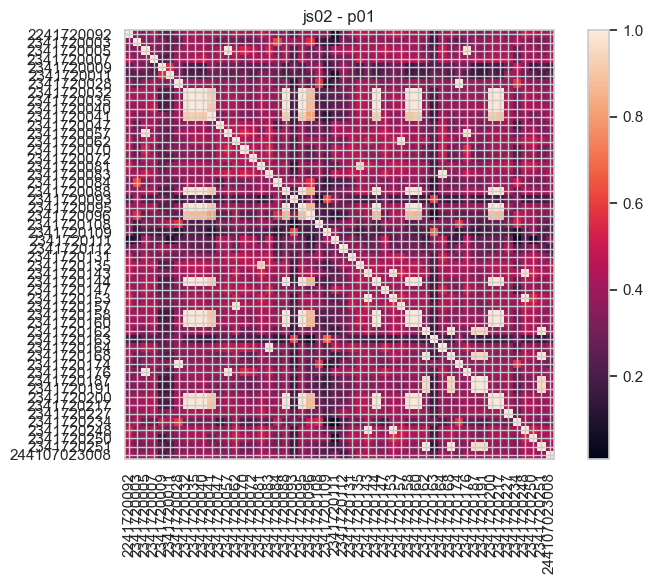

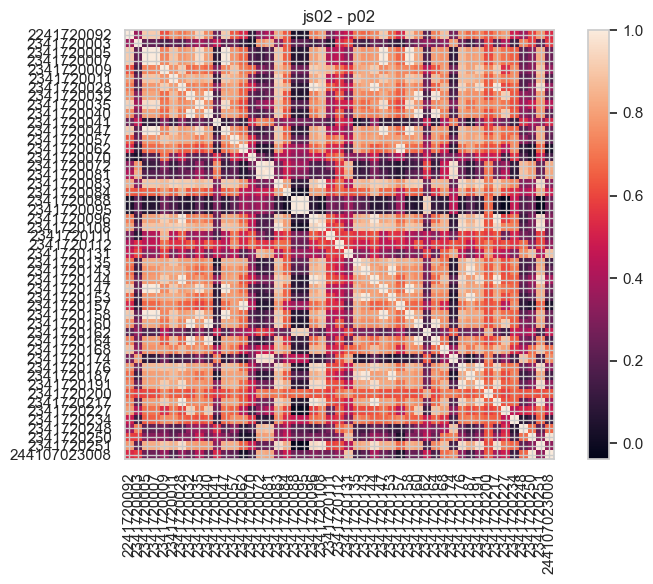

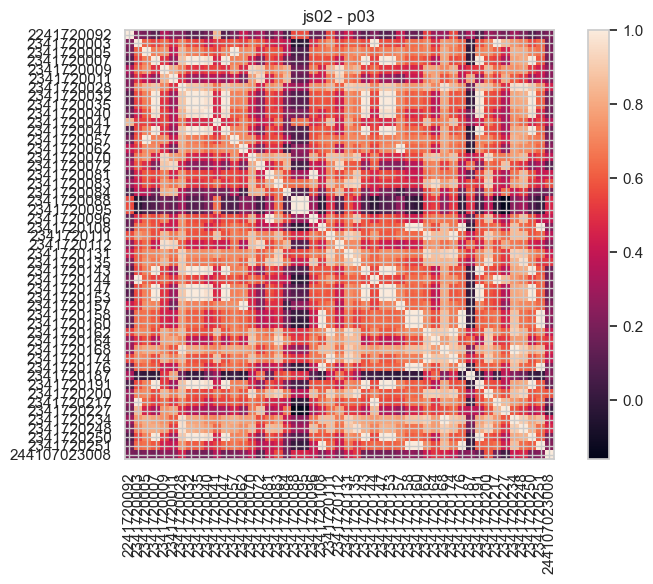

----------------------------------------------------------------------
Total Heatmap Disimpan        : 48
Preview Ditampilkan           : 3


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def build_similarity_matrix(df_meta, embeddings):
    """Membangun matrix similarity dan label nim."""
    sim_matrix = cosine_similarity(embeddings)
    labels = df_meta["nim"].astype(str).tolist()
    return sim_matrix, labels


def plot_heatmap(sim_matrix, labels, title, save_path=None, show=True):
    """Plot heatmap similarity."""
    plt.figure(figsize=(8, 6))

    plt.imshow(sim_matrix)
    plt.colorbar()

    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)

    plt.title(title)
    plt.tight_layout()

    # Simpan gambar
    if save_path:
        plt.savefig(save_path)

    # Kontrol tampil / tidak
    if show:
        plt.show()
    else:
        plt.close()


def generate_heatmaps(input_dir, output_dir, max_preview=2):
    """Generate heatmap per file, tampilkan hanya sebagian."""
    os.makedirs(output_dir, exist_ok=True)

    preview_count = 0
    total_saved = 0

    for root, _, files in os.walk(input_dir):
        for file in files:
            if not file.endswith("_embed.pkl"):
                continue
            if file.startswith("eval_"):
                continue

            path = os.path.join(root, file)

            # Load embedding
            df_meta, embeddings, status, _ = load_embedding_file(path)
            if status != "SUCCESS" or df_meta is None or len(df_meta) < 2:
                continue

            modul = df_meta.loc[0, "modul"]
            filename = df_meta.loc[0, "file"]

            # Build similarity
            sim_matrix, labels = build_similarity_matrix(df_meta, embeddings)

            # Path simpan
            save_path = os.path.join(
                output_dir,
                f"{modul}_{filename.replace('.py','')}_heatmap.png"
            )
            # Tentukan apakah ditampilkan
            show_plot = preview_count < max_preview
            # Plot
            plot_heatmap(
                sim_matrix,
                labels,
                title=f"{modul} - {filename}",
                save_path=save_path,
                show=show_plot
            )

            if show_plot:
                preview_count += 1

            total_saved += 1

    return total_saved, preview_count


# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_DIR = os.path.join(DIRS['LOGS'], "heatmap")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*70)
print(f"{' HEATMAP VISUALIZATION ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Output Directory':<30}: {OUTPUT_DIR}")

total_saved, preview_count = generate_heatmaps(
    INPUT_DIR,
    OUTPUT_DIR,
    max_preview=3
)

print("-"*70)
print(f"{'Total Heatmap Disimpan':<30}: {total_saved}")
print(f"{'Preview Ditampilkan':<30}: {preview_count}")
print("="*70)